# 05 — Baseline MLP sobre embeddings de CLIP

Este notebook establece un modelo de referencia sencillo y reproducible. Concatena los embeddings `static`, `gripper` y textual de CLIP (512 + 512 + 512 = 1536) y entrena únicamente un MLP para predecir una acción de ocho componentes: seis físicas y dos binarias. No se busca optimizar al máximo el rendimiento, sino obtener un punto de comparación razonable para el futuro Transformer de fusión.

## 1. Configuración e imports

Se reutiliza la semilla 42 de los notebooks anteriores. El notebook trabaja directamente con el caché generado por `04_clip_embeddings`, sin cargar imágenes ni vídeos.

In [10]:
from pathlib import Path
import json, os, random, sys, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

ROOT_DIR = Path(os.getcwd()).resolve().parent
if str(ROOT_DIR) not in sys.path: sys.path.append(str(ROOT_DIR))
from src.project_config import PROJECT_DIR, CHECKPOINTS_DIR, RESULTS_DIR, FIGURES_DIR, CACHE_DIR as SHARED_CACHE_DIR, ensure_project_dirs, experiment_dirs
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CACHE_DIR = SHARED_CACHE_DIR
FIGURES_DIR = FIGURES_DIR; RESULTS_DIR = RESULTS_DIR; CHECKPOINTS_DIR = CHECKPOINTS_DIR
IMAGES_DIR = FIGURES_DIR  # Compatibilidad con el nombre usado por las celdas de gráficas.
for directory in (IMAGES_DIR, RESULTS_DIR, CHECKPOINTS_DIR): directory.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 128; LEARNING_RATE = 1e-3; EPOCHS = 25; DROPOUT = 0.10; NUM_WORKERS = 0
print(f'Dispositivo: {DEVICE} | semilla: {SEED}')
print(f'Caché: {CACHE_DIR}')
# Rutas compartidas: no dependen del directorio desde el que se abra el notebook.
ROOT_DIR = PROJECT_DIR
ensure_project_dirs()

RUTAS_EXPERIMENTO = experiment_dirs('baseline_mlp_binary_phase1')
CHECKPOINTS_DIR = RUTAS_EXPERIMENTO['checkpoints']
RESULTS_DIR = RUTAS_EXPERIMENTO['results']
IMAGES_DIR = RUTAS_EXPERIMENTO['figures']


Dispositivo: cpu | semilla: 42
Caché: C:\TFM_Codigo\TFM-VLA\data\cache_embeddings


## 2. Carga de embeddings cacheados

Cada `.npz` contiene `imagenes_static`, `imagenes_gripper`, `textos` y `acciones` para una partición. Se comprueba el formato y las dimensiones esperadas.

In [2]:
def cargar_particion(nombre):
    ruta = CACHE_DIR / f'{nombre}.npz'
    if not ruta.exists():
        raise FileNotFoundError(f'No existe {ruta}. Ejecuta primero 04_clip_embeddings.ipynb.')
    with np.load(ruta) as datos:
        requeridas = {'imagenes_static', 'imagenes_gripper', 'textos', 'acciones'}
        if not requeridas.issubset(datos.files): raise KeyError(f'Claves esperadas: {requeridas}')
        static = np.asarray(datos['imagenes_static'], dtype=np.float32)
        gripper = np.asarray(datos['imagenes_gripper'], dtype=np.float32)
        textual = np.asarray(datos['textos'], dtype=np.float32)
        acciones = np.asarray(datos['acciones'], dtype=np.float32)
    if not (static.ndim == gripper.ndim == textual.ndim == acciones.ndim == 2): raise ValueError(f'{nombre}: arrays no 2D')
    if not (len(static) == len(gripper) == len(textual) == len(acciones)): raise ValueError(f'{nombre}: tamaños inconsistentes')
    if static.shape[1] != 512 or gripper.shape[1] != 512 or textual.shape[1] != 512 or acciones.shape[1] != 8: raise ValueError(f'{nombre}: dimensiones inesperadas')
    return static, gripper, textual, acciones
particiones = {n: cargar_particion(n) for n in ('train','validation','test')}
for n,(s,g,t,a) in particiones.items():
    print(f'{n:10s}: static={s.shape}, gripper={g.shape}, textual={t.shape}, acciones={a.shape}')
    assert np.isfinite(s).all() and np.isfinite(g).all() and np.isfinite(t).all() and np.isfinite(a).all()

train     : static=(190212, 512), gripper=(190212, 512), textual=(190212, 512), acciones=(190212, 8)
validation: static=(23760, 512), gripper=(23760, 512), textual=(23760, 512), acciones=(23760, 8)
test      : static=(23826, 512), gripper=(23826, 512), textual=(23826, 512), acciones=(23826, 8)


## 3. Preparación de train y validation

El baseline concatena los embeddings `static`, `gripper` y textual. Test no participa en el desarrollo; queda reservado para el notebook 09.

In [3]:
def construir_entrada(datos):
    static, gripper, textual, acciones = datos
    return np.concatenate([static, gripper, textual], axis=1), acciones
entradas = {n: construir_entrada(d) for n,d in particiones.items()}
datasets = {n: TensorDataset(torch.from_numpy(x), torch.from_numpy(y)) for n,(x,y) in entradas.items()}
generator = torch.Generator().manual_seed(SEED)
loaders = {'train': DataLoader(datasets['train'], batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=NUM_WORKERS), 'validation': DataLoader(datasets['validation'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)}
print({n: len(ds) for n,ds in datasets.items()}); print('Entrada:', entradas['train'][0].shape[1]); assert entradas['train'][0].shape[1] == 1536

{'train': 190212, 'validation': 23760, 'test': 23826}
Entrada: 1536


## 4. Modelo BaselineMLP y comprobación

La red sigue 1536 → 512 → 256 → 8, con ReLU y dropout entre capas ocultas.

In [4]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=1536, hidden_dim_1=512, hidden_dim_2=256, output_dim=8, dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim, hidden_dim_1), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim_1, hidden_dim_2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim_2, output_dim), nn.Sigmoid())
    def forward(self, x): return self.network(x)
model = BaselineMLP(dropout=DROPOUT).to(DEVICE)
x_batch,y_batch = next(iter(loaders['train']))
with torch.no_grad(): y_batch_pred = model(x_batch.to(DEVICE))
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Batch:', tuple(x_batch.shape), '| objetivo:', tuple(y_batch.shape), '| salida:', tuple(y_batch_pred.shape)); print(f'Parámetros entrenables: {num_params:,}')
assert y_batch_pred.shape[-1] == 8 and torch.isfinite(y_batch_pred).all() and torch.all((y_batch_pred >= 0) & (y_batch_pred <= 1))

Batch: (128, 1536) | objetivo: (128, 8) | salida: (128, 8)
Parámetros entrenables: 920,328


## 5. Entrenamiento y criterio de pérdida

Se usan MSE para las dimensiones físicas y BCE para `terminate` y la pinza binaria. El checkpoint se selecciona solo por `validation_loss`; test permanece reservado para el notebook 09.

In [5]:
from src.train import action_loss
criterion = action_loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
history=[]; best_val_loss=float('inf'); best_epoch=0; best_path=CHECKPOINTS_DIR/'baseline_mlp_binary_best.pt'
training_start=time.perf_counter()
for epoch in range(1,EPOCHS+1):
    epoch_start=time.perf_counter(); model.train(); train_sum=train_count=0
    for features,targets in loaders['train']:
        features,targets=features.to(DEVICE),targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        # MSE(x..rz) + BCE(terminate) + BCE(gripper binaria).
        loss=criterion(model(features),targets); loss.backward(); optimizer.step()
        train_sum+=loss.item()*len(features); train_count+=len(features)
    model.eval(); val_sum=val_count=0
    with torch.no_grad():
        for features,targets in loaders['validation']:
            features,targets=features.to(DEVICE),targets.to(DEVICE)
            val_sum+=criterion(model(features),targets).item()*len(features); val_count+=len(features)
    train_loss=train_sum/train_count; val_loss=val_sum/val_count; epoch_time=time.perf_counter()-epoch_start
    history.append({'epoch':epoch,'train_loss':train_loss,'validation_loss':val_loss,'time_epoch_seconds':epoch_time})
    if val_loss < best_val_loss:
        best_val_loss=val_loss; best_epoch=epoch
        torch.save({'model_state_dict':model.state_dict(),'optimizer_state_dict':optimizer.state_dict(),'epoch':epoch,'validation_loss':val_loss},best_path)
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.6f} | validation_loss={val_loss:.6f} | {epoch_time:.1f}s')
total_training_time=time.perf_counter()-training_start
print(f'Tiempo total: {total_training_time:.2f}s | mejor época: {best_epoch}')


Epoch 01/25 | train_loss=0.487684 | validation_loss=0.404283 | 41.8s
Epoch 02/25 | train_loss=0.358325 | validation_loss=0.384633 | 39.9s
Epoch 03/25 | train_loss=0.306490 | validation_loss=0.394071 | 35.7s
Epoch 04/25 | train_loss=0.278074 | validation_loss=0.317871 | 34.8s
Epoch 05/25 | train_loss=0.261093 | validation_loss=0.322742 | 35.7s
Epoch 06/25 | train_loss=0.245083 | validation_loss=0.312325 | 36.5s
Epoch 07/25 | train_loss=0.231254 | validation_loss=0.297458 | 36.1s
Epoch 08/25 | train_loss=0.220094 | validation_loss=0.300512 | 38.2s
Epoch 09/25 | train_loss=0.210161 | validation_loss=0.292217 | 37.6s
Epoch 10/25 | train_loss=0.203022 | validation_loss=0.285595 | 55.0s
Epoch 11/25 | train_loss=0.194801 | validation_loss=0.290085 | 38.2s
Epoch 12/25 | train_loss=0.191062 | validation_loss=0.289146 | 36.1s
Epoch 13/25 | train_loss=0.182442 | validation_loss=0.283936 | 35.4s
Epoch 14/25 | train_loss=0.177086 | validation_loss=0.305026 | 34.8s
Epoch 15/25 | train_loss=0.175005 

## 6. Curvas de entrenamiento

Las curvas ayudan a comprobar la convergencia y a identificar sobreajuste.

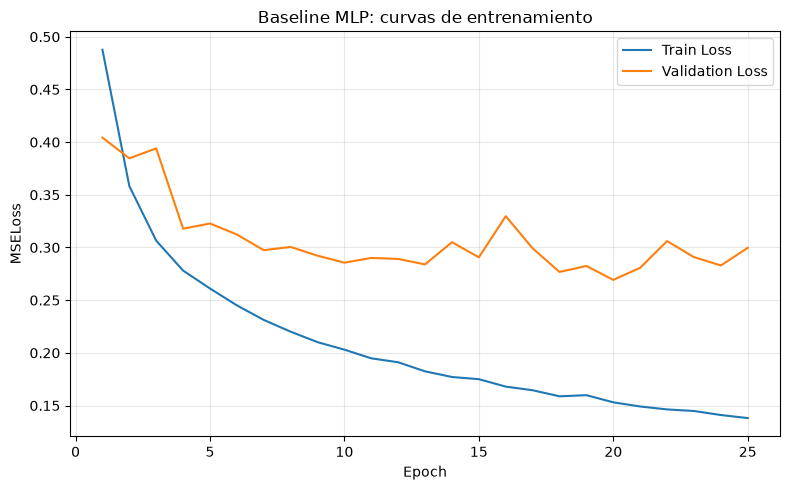

Gráfica guardada en C:\TFM_Codigo\TFM-VLA\figures\baseline_mlp_binary_phase1\baseline_mlp_loss.png


In [6]:
plt.figure(figsize=(8,5)); plt.plot([r['epoch'] for r in history],[r['train_loss'] for r in history],label='Train Loss'); plt.plot([r['epoch'] for r in history],[r['validation_loss'] for r in history],label='Validation Loss'); plt.xlabel('Epoch'); plt.ylabel('MSELoss'); plt.title('Baseline MLP: curvas de entrenamiento'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
loss_plot_path=IMAGES_DIR/'baseline_mlp_loss.png'; plt.savefig(loss_plot_path,dpi=150); plt.show(); print(f'Gráfica guardada en {loss_plot_path}')

## 7. Validación y ó del checkpoint

Se recupera el mejor checkpoint y se inspecciona validation. No se calcula ninguna é final sobre test: esa evaluación corresponde al notebook 09.

In [7]:
checkpoint=torch.load(best_path,map_location=DEVICE); model.load_state_dict(checkpoint['model_state_dict']); model.eval(); predicciones=[]; objetivos=[]
with torch.no_grad():
    for features,targets in loaders['validation']:
        predicciones.append(model(features.to(DEVICE)).cpu()); objetivos.append(targets)
y_pred=torch.cat(predicciones); y_true=torch.cat(objetivos); error=y_pred-y_true
print(f'Checkpoint recuperado: época {checkpoint["epoch"]}, validation loss={checkpoint["validation_loss"]:.6f}')
print('Validación preparada; test queda reservado para 09.')


Checkpoint recuperado: época 20, validation loss=0.269252
Validación preparada; test queda reservado para 09.


### 7.1 Métricas predictivas compartidas de validation

Las és comunes se reutilizarán en baseline, VLA y evaluación final. Los resultados predictivos no incluyen tiempos ni parámetros.

In [8]:
from src.evaluation import evaluate_actions
with (ROOT_DIR / 'data' / 'parametros_normalizacion.json').open(encoding='utf-8') as archivo:
    parametros_normalizacion = json.load(archivo)
metricas_validacion = evaluate_actions(y_pred.numpy(), y_true.numpy(), np.asarray(parametros_normalizacion['minimo'], dtype=np.float32), np.asarray(parametros_normalizacion['escala'], dtype=np.float32))
print(json.dumps(metricas_validacion, indent=2, ensure_ascii=False))


{
  "continuous_normalized": {
    "mae": 0.03299524262547493,
    "rmse": 0.04788916930556297,
    "mae_by_component": {
      "x": 0.02505253255367279,
      "y": 0.039272792637348175,
      "z": 0.04319726675748825,
      "rx": 0.018915485590696335,
      "ry": 0.030084604397416115,
      "rz": 0.04144877940416336
    },
    "rmse_by_component": {
      "x": 0.03468984737992287,
      "y": 0.05665126442909241,
      "z": 0.06099625676870346,
      "rx": 0.028180278837680817,
      "ry": 0.04315141588449478,
      "rz": 0.0636659488081932
    }
  },
  "xyz_denormalized_cosine_similarity": 0.4176352620124817,
  "terminate": {
    "accuracy": 0.9848063973063973,
    "precision": 0.3333333333333333,
    "recall": 0.002777777777777778,
    "f1": 0.005509641873278238,
    "real_positives": 360,
    "predicted_positives": 3,
    "true_positives": 1
  },
  "gripper": {
    "accuracy": 0.9276094276094277,
    "precision": 0.9025591501690005,
    "recall": 0.9293029730535945,
    "f1": 0.9157

## 8. Eficiencia computacional

Los tiempos se almacenan separados de las és de acciones. La ruta cacheada y la ruta completa se identifican explícitamente y usan las mismas muestras y dispositivo.

In [11]:
from src.evaluation import benchmark_inference
N_MUESTRAS_TIEMPO = min(32, len(entradas['validation'][0]))
features_tiempo = torch.from_numpy(entradas['validation'][0][:N_MUESTRAS_TIEMPO]).to(DEVICE)
eficiencia_cache = benchmark_inference(lambda: model(features_tiempo), N_MUESTRAS_TIEMPO)
eficiencia_cache['route'] = 'embeddings_cacheados_sin_CLIP'
from src.clip_encoder import CLIPEncoder
from src.dataset import VLADataset
particion_validacion = pd.read_parquet(ROOT_DIR / 'data' / 'procesado_clip' / 'validation.parquet').head(N_MUESTRAS_TIEMPO)
encoder_tiempo = CLIPEncoder('ViT-B-32', 'openai', DEVICE, congelar=True)
dataset_tiempo = VLADataset(particion_validacion, encoder_tiempo.preprocess, encoder_tiempo.tokenizer)
imagenes_static_tiempo, imagenes_gripper_tiempo, tokens_tiempo, _ = next(iter(DataLoader(dataset_tiempo, batch_size=N_MUESTRAS_TIEMPO, shuffle=False)))
def predecir_completo_baseline():
    # CLIP visual de ambas vistas y textual forman parte de esta ruta completa.
    return model(torch.cat([encoder_tiempo.encode_image(imagenes_static_tiempo), encoder_tiempo.encode_image(imagenes_gripper_tiempo), encoder_tiempo.encode_text(tokens_tiempo)], dim=1))
eficiencia_completa = benchmark_inference(predecir_completo_baseline, N_MUESTRAS_TIEMPO)
eficiencia_completa['route'] = 'imagenes_static_gripper_instruccion_CLIP_y_baseline'
parametros_clip = sum(parametro.numel() for parametro in encoder_tiempo.modelo.parameters())
eficiencia_sistema = {'device': str(DEVICE), 'total_parameters_including_clip': parametros_clip + num_params, 'trainable_parameters': num_params, 'cached_embedding_inference': eficiencia_cache, 'full_inference_including_clip': eficiencia_completa}
print(json.dumps(eficiencia_sistema, indent=2, ensure_ascii=False))


c:\TFM_Codigo\TFM-VLA\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


{
  "device": "cpu",
  "total_parameters_including_clip": 152197641,
  "trainable_parameters": 920328,
  "cached_embedding_inference": {
    "samples": 32,
    "repeats": 5,
    "mean_ms_per_sample": 0.4847112504648976,
    "std_ms_per_sample": 0.7828751379159923,
    "route": "embeddings_cacheados_sin_CLIP"
  },
  "full_inference_including_clip": {
    "samples": 32,
    "repeats": 5,
    "mean_ms_per_sample": 282.1897293753864,
    "std_ms_per_sample": 16.245631580679213,
    "route": "imagenes_static_gripper_instruccion_CLIP_y_baseline"
  }
}


## 8. Inspección de predicciones

Se imprimen diez muestras con acción real, acción predicha y error absoluto componente a componente.

In [ ]:
for i in range(min(10,len(y_true))):
    print(f'Muestra {i+1}'); print('  Acción real:    ',np.round(y_true[i].numpy(),4)); print('  Acción predicha:',np.round(y_pred[i].numpy(),4)); print('  Error absoluto: ',np.round(error[i].abs().numpy(),4))

Muestra 1
  Acción real:     [0.     0.7644 0.5444 0.2721 0.4641 0.5407 0.254  1.    ]
  Acción predicha: [0.0353 0.7298 0.5776 0.3101 0.4592 0.5039 0.4162 1.0026]
  Error absoluto:  [0.0353 0.0346 0.0332 0.038  0.0049 0.0368 0.1622 0.0026]
Muestra 2
  Acción real:     [0.     0.773  0.5524 0.2559 0.3838 0.4283 0.1611 1.    ]
  Acción predicha: [0.0531 0.7256 0.5652 0.2765 0.4618 0.5117 0.3935 1.0057]
  Error absoluto:  [0.0531 0.0474 0.0128 0.0207 0.078  0.0834 0.2325 0.0057]
Muestra 3
  Acción real:     [0.     0.764  0.5611 0.2592 0.4349 0.4871 0.2034 1.    ]
  Acción predicha: [0.0493 0.7351 0.5605 0.2846 0.4641 0.5018 0.3899 0.9911]
  Error absoluto:  [0.0493 0.0288 0.0006 0.0254 0.0292 0.0146 0.1865 0.0089]
Muestra 4
  Acción real:     [0.     0.7595 0.5754 0.2049 0.461  0.6    0.2329 1.    ]
  Acción predicha: [0.052  0.7358 0.5587 0.2636 0.4633 0.5103 0.3905 0.9849]
  Error absoluto:  [0.052  0.0236 0.0167 0.0587 0.0023 0.0897 0.1576 0.0151]
Muestra 5
  Acción real:     [0.    

## 9. Resultados reutilizables

El JSON registra configuración, historial y el checkpoint de menor pérdida de validación. No contiene resultados de test.

In [ ]:
resultado={'model':'BaselineMLP','loss':'MSE(x..rz) + BCE(terminate) + BCE(gripper binaria)','seed':SEED,'device':str(DEVICE),'batch_size':BATCH_SIZE,'learning_rate':LEARNING_RATE,'weight_decay':1e-4,'epochs_requested':EPOCHS,'best_epoch':best_epoch,'best_validation_loss':best_val_loss,'total_training_time_seconds':total_training_time,'test_used':False,'validation_action_metrics':metricas_validacion,'computational_efficiency':eficiencia_sistema,'history':history,'artifacts':{'checkpoint':str(best_path),'loss_plot':str(loss_plot_path)}}
results_path=RESULTS_DIR/'baseline_mlp_binary_validation.json'
with results_path.open('w',encoding='utf-8') as archivo: json.dump(resultado,archivo,indent=2,ensure_ascii=False)
print(f'Resultados guardados en {results_path}; checkpoint listo para 09.')


Resultados guardados en C:\TFM_Codigo\TFM-VLA\results\baseline_mlp_results.json
Baseline MLP completado correctamente.


## Resumen de resultados

Este notebook utiliza la configuración centralizada, entrena un baseline con las vistas `static` y `gripper`, y deja los artefactos del experimento en una carpeta propia.